In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from src.logger.logger import logging

# Settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

# Load cleaned data
df = pd.read_excel('../data/processed/pulsemap_cleaned.xlsx')

logging.info("Risk scoring notebook started")
print("Shape:", df.shape)
print(df.head(3))

Shape: (707, 21)
                 district                      state  bmi_below_normal_w  \
0                Nicobars  Andaman & Nicobar Islands                8.18   
1  North & Middle Andaman  Andaman & Nicobar Islands                8.55   
2           South Andaman  Andaman & Nicobar Islands               10.00   

   overweight_obese_w  anaemia_w  blood_sugar_w  blood_sugar_m  bp_elevated_w  \
0               39.11      38.30          13.05          15.39          35.36   
1               35.89      62.07          16.72          18.28          27.40   
2               39.01      57.66          18.41          18.10          22.95   

   bp_elevated_m  cervical_screening_w  ...  oral_exam_w  tobacco_w  \
0          46.97                 13.35  ...         5.37      63.46   
1          32.20                  1.70  ...        15.84      46.77   
2          26.90                  1.32  ...         8.00      19.60   

   tobacco_m  alcohol_w  alcohol_m  literacy_w  health_insurance  cl

In [2]:
# Define risk and protective indicators
risk_indicators = [
    'anaemia_w', 'blood_sugar_w', 'blood_sugar_m',
    'bp_elevated_w', 'bp_elevated_m',
    'tobacco_w', 'tobacco_m',
    'alcohol_w', 'alcohol_m',
    'bmi_below_normal_w'
]

protective_indicators = [
    'literacy_w', 'clean_fuel', 'sanitation',
    'clean_water', 'health_insurance',
    'cervical_screening_w', 'breast_exam_w', 'oral_exam_w',
    'overweight_obese_w'
]

print("Risk indicators:", len(risk_indicators))
print("Protective indicators:", len(protective_indicators))
print("Total:", len(risk_indicators) + len(protective_indicators))

Risk indicators: 10
Protective indicators: 9
Total: 19


In [3]:
# Normalize all indicators
scaler = MinMaxScaler()

df_scaled = df.copy()

# Risk indicators — higher = higher risk (keep as is)
df_scaled[risk_indicators] = scaler.fit_transform(df[risk_indicators])

# Protective indicators — higher = lower risk (invert)
df_scaled[protective_indicators] = 1 - scaler.fit_transform(df[protective_indicators])

# Calculate weighted risk score
# Risk indicators weight: 0.7 total
# Protective indicators weight: 0.3 total
risk_weight = 0.7 / len(risk_indicators)
protective_weight = 0.3 / len(protective_indicators)

df['risk_score'] = (
    df_scaled[risk_indicators].sum(axis=1) * risk_weight +
    df_scaled[protective_indicators].sum(axis=1) * protective_weight
)

# Scale to 0-100
df['risk_score'] = (
    (df['risk_score'] - df['risk_score'].min()) /
    (df['risk_score'].max() - df['risk_score'].min()) * 100
).round(2)

print("Risk Score Stats:")
print(df['risk_score'].describe().round(2))

Risk Score Stats:
count    707.00
mean      39.57
std       15.96
min        0.00
25%       28.08
50%       37.24
75%       49.53
max      100.00
Name: risk_score, dtype: float64


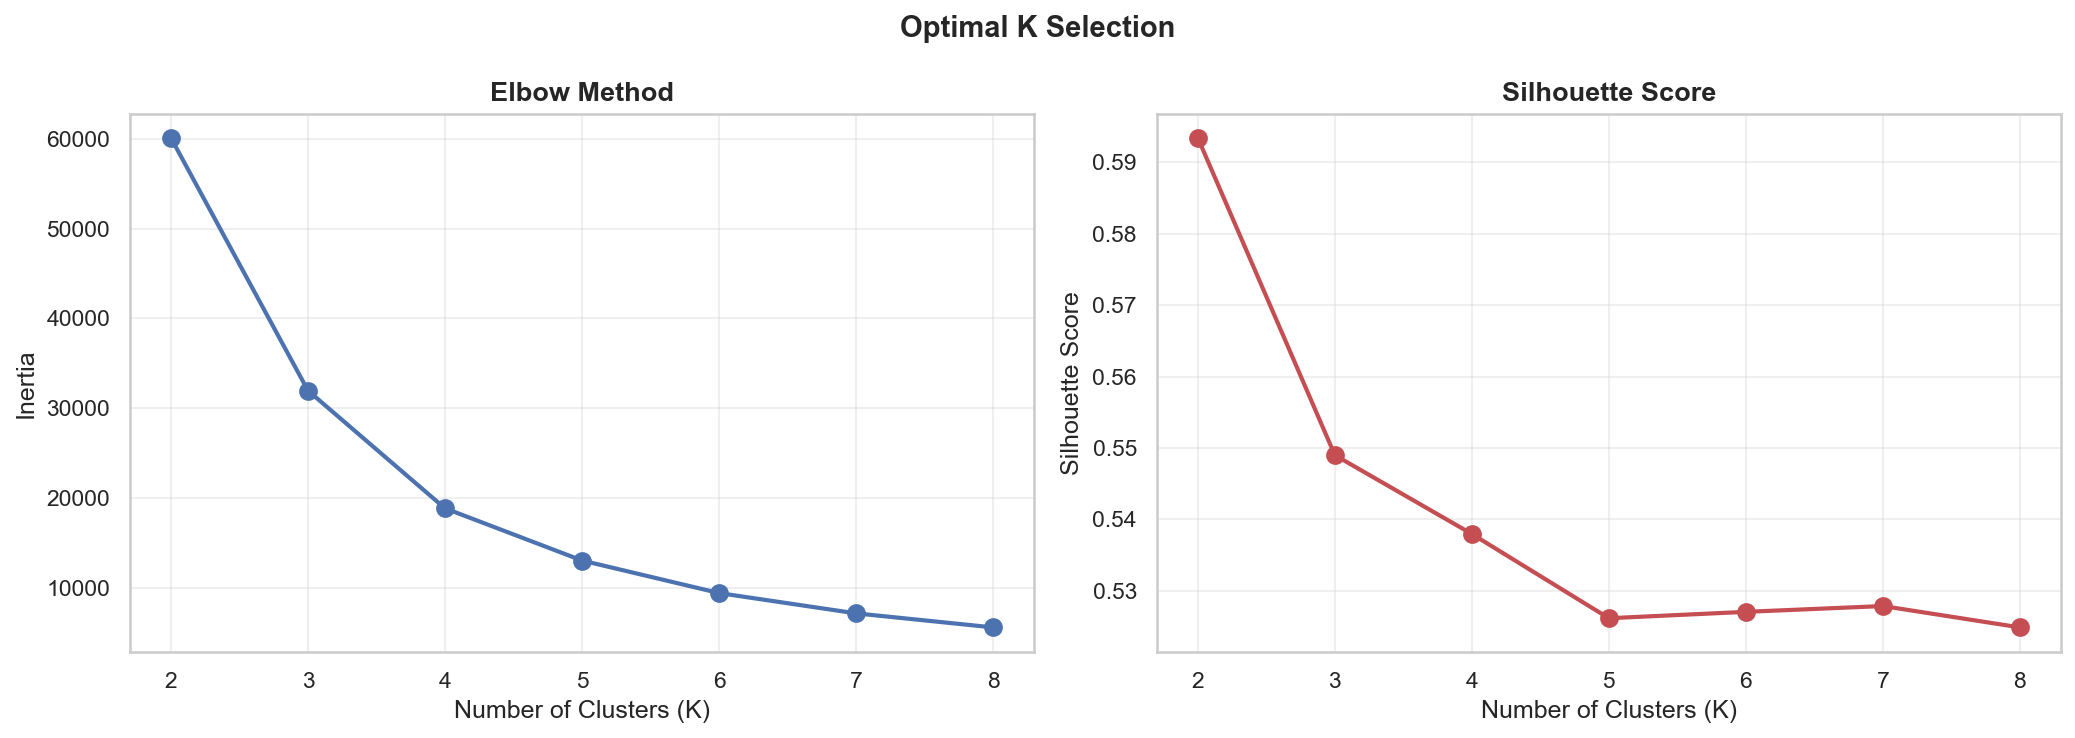

Silhouette Scores:
K=2: 0.5934
K=3: 0.5490
K=4: 0.5379
K=5: 0.5261
K=6: 0.5270
K=7: 0.5279
K=8: 0.5249


In [4]:
# Find optimal number of clusters using Elbow method
inertias = []
silhouette_scores = []
K = range(2, 9)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df[['risk_score']])
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df[['risk_score']], 
                                               kmeans.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(K, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.suptitle('Optimal K Selection', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/09_optimal_k.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Silhouette Scores:")
for k, score in zip(K, silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=4 was selected over K=2 (highest silhouette score) as it provides 
meaningful business segmentation — four risk tiers enable actionable 
differentiation for healthcare resource allocation, while K=2 offers 
only binary classification with limited operational value.

In [5]:
# Apply KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['risk_score']])

# Label clusters meaningfully based on risk score mean
cluster_means = df.groupby('cluster')['risk_score'].mean().sort_values()
tier_map = {
    cluster_means.index[0]: 'Low Risk',
    cluster_means.index[1]: 'Moderate Risk',
    cluster_means.index[2]: 'High Risk',
    cluster_means.index[3]: 'Critical Risk'
}
df['risk_tier'] = df['cluster'].map(tier_map)

# Distribution of tiers
print("Risk Tier Distribution:")
print(df['risk_tier'].value_counts())
print("\nMean risk score per tier:")
print(df.groupby('risk_tier')['risk_score'].mean().round(2).sort_values())

Risk Tier Distribution:
risk_tier
Moderate Risk    253
High Risk        217
Low Risk         160
Critical Risk     77
Name: count, dtype: int64

Mean risk score per tier:
risk_tier
Low Risk         20.77
Moderate Risk    33.55
High Risk        49.47
Critical Risk    70.56
Name: risk_score, dtype: float64


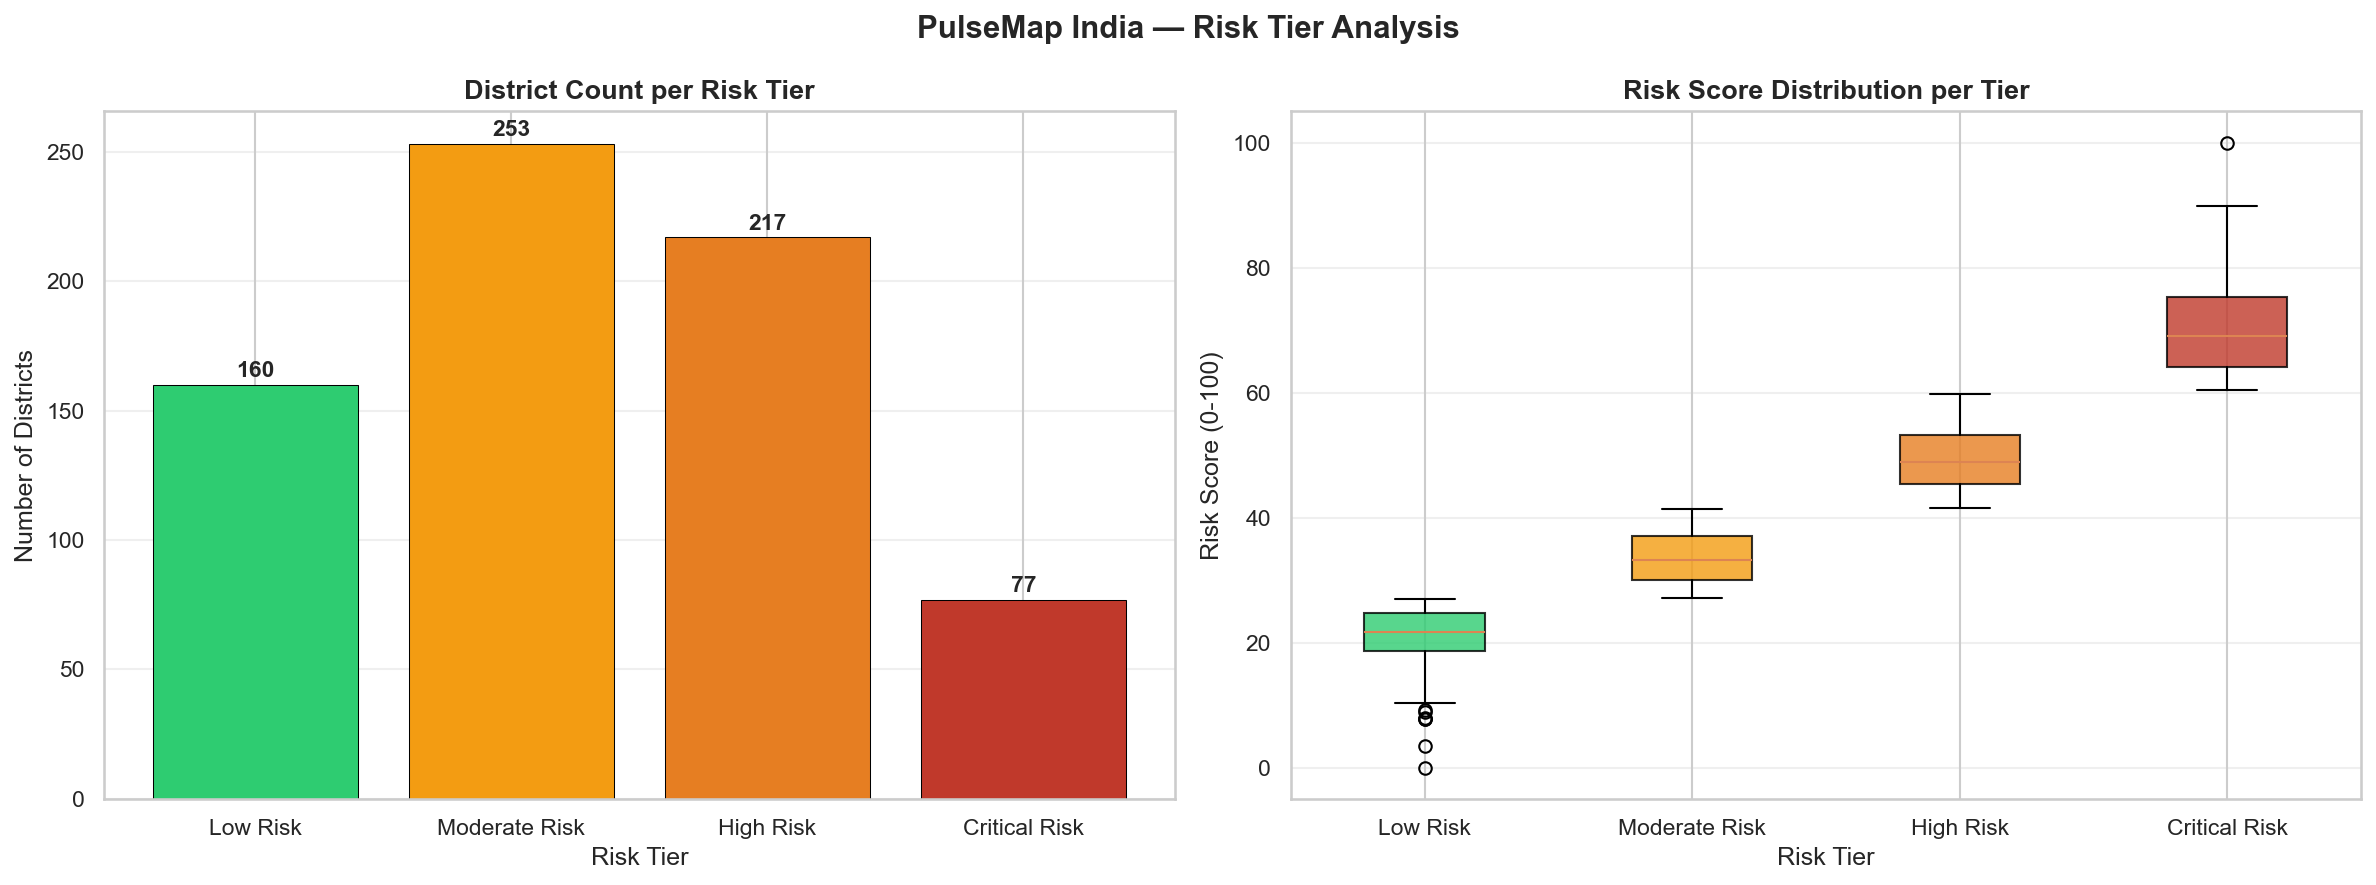

Done


In [6]:
# Risk tier visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color map
tier_colors = {
    'Low Risk': '#2ecc71',
    'Moderate Risk': '#f39c12',
    'High Risk': '#e67e22',
    'Critical Risk': '#c0392b'
}

# Bar chart — district count per tier
tier_order = ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
counts = df['risk_tier'].value_counts()[tier_order]
colors = [tier_colors[t] for t in tier_order]

axes[0].bar(tier_order, counts.values, color=colors, 
            edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', 
                 fontweight='bold', fontsize=11)
axes[0].set_title('District Count per Risk Tier',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Districts', fontsize=12)
axes[0].set_xlabel('Risk Tier', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Box plot — risk score distribution per tier
tier_data = [df[df['risk_tier']==t]['risk_score'].values 
             for t in tier_order]
bp = axes[1].boxplot(tier_data, labels=tier_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Risk Score Distribution per Tier',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('Risk Score (0-100)', fontsize=12)
axes[1].set_xlabel('Risk Tier', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('PulseMap India — Risk Tier Analysis',
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('../reports/10_risk_tiers.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Risk tier visualization saved")
print("Done")

## Risk Scoring — K-Means Clustering Results

### Cluster Selection
K=4 was selected based on Elbow Method and business relevance.
While K=2 had the highest silhouette score (0.59), K=4 provides
meaningful operational segmentation for healthcare resource allocation.
The elbow curve clearly flattens after K=4, confirming the choice.

### Risk Tier Distribution

| Risk Tier | Districts | Mean Score | Score Range |
|---|---|---|---|
| Low Risk | 160 (22.6%) | 20.77 | 0 - 30 |
| Moderate Risk | 253 (35.8%) | 33.55 | 30 - 43 |
| High Risk | 217 (30.7%) | 49.47 | 43 - 60 |
| Critical Risk | 77 (10.9%) | 70.56 | 60 - 100 |

### Key Observations

- **77 Critical Risk districts (10.9%)** these represent India's 
  most vulnerable populations requiring immediate intervention.

- **470 districts (66.5%) fall in High or Critical Risk** 
  majority of India's districts need active health intervention, 
  not just monitoring.

- **Box plot shows clean separation** between tiers K-Means 
  clustering worked well, tiers are well-defined with minimal overlap.

- **Critical Risk tier has widest spread** some districts score 
  near 100, indicating extreme multi-dimensional health deprivation.

### Business Implication
- **Health Insurers:** Price premiums by risk tier Critical Risk 
  districts warrant 3x higher claim probability than Low Risk.
- **NGOs:** Focus 80% resources on 77 Critical Risk districts 
  for maximum impact per rupee spent.
- **Government:** 470 High+Critical districts need state-level 
  coordinated programs, not district-by-district approach.

In [7]:
# Save final dataset
df.to_excel('../data/processed/pulsemap_final.xlsx', index=False)
df.to_excel('../artifacts/pulsemap_final.xlsx', index=False)

logging.info("Final dataset saved to data/processed and artifacts")
print("Final dataset saved")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Final dataset saved
Shape: (707, 24)
Columns: ['district', 'state', 'bmi_below_normal_w', 'overweight_obese_w', 'anaemia_w', 'blood_sugar_w', 'blood_sugar_m', 'bp_elevated_w', 'bp_elevated_m', 'cervical_screening_w', 'breast_exam_w', 'oral_exam_w', 'tobacco_w', 'tobacco_m', 'alcohol_w', 'alcohol_m', 'literacy_w', 'health_insurance', 'clean_water', 'sanitation', 'clean_fuel', 'risk_score', 'cluster', 'risk_tier']
